# Lasso Regression

## Objective

In this notebook, we will practice:

- Linear Regression baseline
- Feature Scaling
- Lasso Regression
- L1 Regularization
- Alpha parameter
- Coefficient shrinkage
- Feature selection
- Zero coefficients
- Model evaluation
- Comparing different alpha values

## Dataset

Heart Failure Clinical Records Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv(
    "../../heart_failure_clinical_records_dataset-selected-columns.csv"
)

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
0,75.0,0,582,0,20,1,265000.00,1.9,130,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0


In [4]:
print("Shape:", df.shape)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)



Shape: (299, 10)
Missing Values: 0


In [5]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000


# Preparing Data

We will use the following numerical features:

- age
- creatinine_phosphokinase
- ejection_fraction
- platelets
- serum_sodium

Target:

- serum_creatinine

In [6]:
features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_sodium"
]

X = df[features]

y = df["serum_creatinine"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (299, 5)
y Shape: (299,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

Training Rows: 239
Testing Rows: 60


# Linear Regression Baseline

First, we train a normal Linear Regression model.

This provides a baseline for comparison with Lasso Regression.

In [8]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline.fit(
    X_train,
    y_train
)

linear_pred = linear_pipeline.predict(
    X_test
)

In [9]:
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear Regression")
print("MAE :", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²  :", round(linear_r2, 3))

Linear Regression
MAE : 0.582
RMSE: 1.172
R²  : 0.01


# Lasso Regression

Lasso Regression uses L1 Regularization.

Unlike Ridge, Lasso can make some coefficients exactly zero.

This allows Lasso to perform feature selection.


In [10]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1))
])

lasso_pipeline.fit(
    X_train,
    y_train
)

lasso_pred = lasso_pipeline.predict(
    X_test
)

In [11]:
lasso_mae = mean_absolute_error(
    y_test,
    lasso_pred
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lasso_pred
    )
)

lasso_r2 = r2_score(
    y_test,
    lasso_pred
)

print("Lasso Regression")
print("MAE :", round(lasso_mae, 3))
print("RMSE:", round(lasso_rmse, 3))
print("R²  :", round(lasso_r2, 3))

Lasso Regression
MAE : 0.573
RMSE: 1.172
R²  : 0.01


In [12]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Lasso Regression"
    ],
    "MAE": [
        linear_mae,
        lasso_mae
    ],
    "RMSE": [
        linear_rmse,
        lasso_rmse
    ],
    "R²": [
        linear_r2,
        lasso_r2
    ]
})

comparison.round(3)

,Model,MAE,RMSE,R²
0,Linear Regression,0.582,1.172,0.01
1,Lasso Regression,0.573,1.172,0.01


In [13]:
lasso_model = lasso_pipeline.named_steps["model"]

lasso_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": lasso_model.coef_
})

lasso_coefficients.round(4)

,Feature,Coefficient
0,age,0.0106
1,creatinine_phosphokinase,0.0000
2,ejection_fraction,0.0000
3,platelets,-0.0000
4,serum_sodium,-0.1192


In [14]:
linear_model = linear_pipeline.named_steps["model"]

coefficient_comparison = pd.DataFrame({
    "Feature": features,
    "Linear Regression": linear_model.coef_,
    "Lasso Regression": lasso_model.coef_
})

coefficient_comparison.round(4)

,Feature,Linear Regression,Lasso Regression
0,age,0.1049,0.0106
1,creatinine_phosphokinase,0.0414,0.0000
2,ejection_fraction,0.0486,0.0000
3,platelets,-0.0629,-0.0000
4,serum_sodium,-0.2217,-0.1192


# Effect of Alpha

We will test different alpha values.

Small alpha:
- Weak regularization
- Less coefficient shrinkage

Large alpha:
- Strong regularization
- More coefficient shrinkage
- More coefficients may become zero

In [15]:
alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10
]

results = []

for alpha in alphas:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha))
    ])

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    coefficients = (
        model.named_steps["lasso"].coef_
    )

    zero_count = np.sum(
        coefficients == 0
    )

    results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Zero Coefficients": zero_count
    })

alpha_results = pd.DataFrame(results)

alpha_results.round(4)

,Alpha,MAE,RMSE,R²,Zero Coefficients
0,0.001,0.5813,1.1718,0.0105,0
1,0.010,0.5760,1.1685,0.0161,0
2,0.100,0.5733,1.1720,0.0102,3
3,1.000,0.5924,1.1784,-0.0008,5
4,10.000,0.5924,1.1784,-0.0008,5


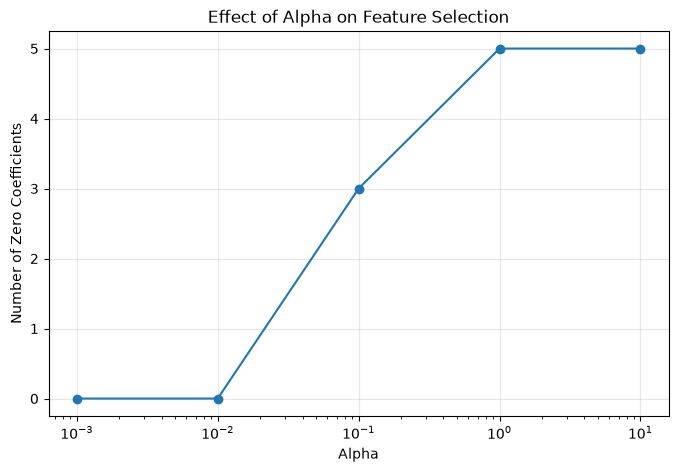

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    alpha_results["Alpha"],
    alpha_results["Zero Coefficients"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Number of Zero Coefficients")

plt.title(
    "Effect of Alpha on Feature Selection"
)

plt.grid(alpha=0.3)

plt.show()

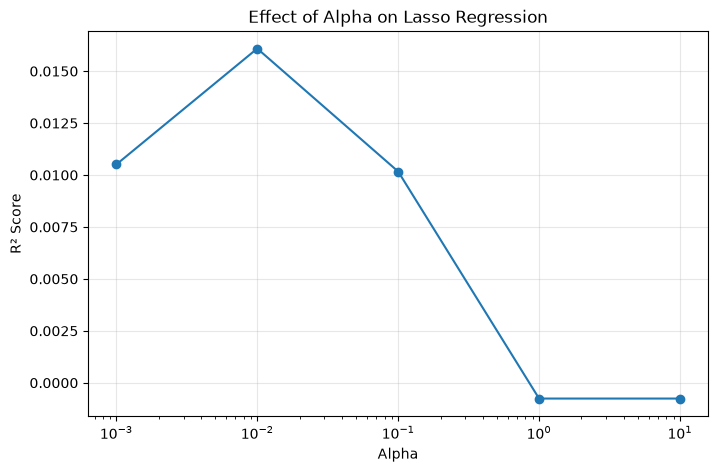

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    alpha_results["Alpha"],
    alpha_results["R²"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("R² Score")

plt.title(
    "Effect of Alpha on Lasso Regression"
)

plt.grid(alpha=0.3)

plt.show()

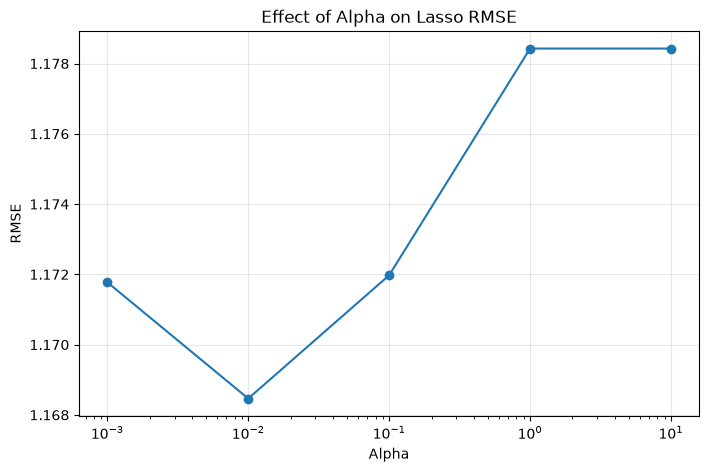

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    alpha_results["Alpha"],
    alpha_results["RMSE"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("RMSE")

plt.title(
    "Effect of Alpha on Lasso RMSE"
)

plt.grid(alpha=0.3)

plt.show()

In [19]:
selected_features = lasso_coefficients[
    lasso_coefficients["Coefficient"] != 0
]

removed_features = lasso_coefficients[
    lasso_coefficients["Coefficient"] == 0
]

print("Selected Features:")
display(selected_features)

print("\nRemoved Features:")
display(removed_features)

Selected Features:


,Feature,Coefficient
0,age,0.010567
4,serum_sodium,-0.119154



Removed Features:


,Feature,Coefficient
1,creatinine_phosphokinase,0.0
2,ejection_fraction,0.0
3,platelets,-0.0


# Summary

## Lasso Regression

Lasso Regression adds L1 regularization to Linear Regression.

## Alpha

- Small alpha → weak regularization
- Large alpha → strong regularization

## Coefficients

Lasso shrinks coefficients toward zero.

Some coefficients can become exactly zero.

## Feature Selection

Zero coefficients allow Lasso to perform automatic feature selection.

## Model Evaluation

We compared models using:

- MAE
- RMSE
- R²

## Important

A larger alpha does not automatically mean a better model.

Alpha should be selected using validation or cross-validation.

Lasso is especially useful when a simpler model with fewer active features is desirable.